In [1]:
# Imports
import pandas as pd
import numpy as np

In [2]:
# Load CSV
df_raw = pd.read_csv("investments_VC.csv", encoding="latin1")

print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (54294, 39)


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Inspect raw columns, types, and missing values
print("Column names:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

print("\nMissing values:")
print(df_raw.isnull().sum().sort_values(ascending=False))

Column names:
['permalink', 'name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']

Data types:
permalink                object
name                     object
homepage_url             object
category_list            object
 market                  object
 funding_total_usd       object
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          float64
founded_at         

In [4]:
# Clean column names
df = df_raw.copy()

# Strip whitespace from column names
df.columns = [col.strip() for col in df.columns]

print(df.columns.tolist())

['permalink', 'name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']


In [5]:
# Clean all object columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace("nan", np.nan)

# Change funding column from string to float
df["funding_total_usd"] = (
    df["funding_total_usd"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["funding_total_usd"] = df["funding_total_usd"].replace({"": np.nan})
df["funding_total_usd"] = pd.to_numeric(df["funding_total_usd"], errors="coerce")

df["funding_total_usd"].describe()

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

In [6]:
# Convert date columns
date_cols = ["founded_at", "first_funding_at", "last_funding_at"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [7]:
# Drop rows where status is missing
df = df[df["status"].notna()].copy()

print("Remaining rows after dropping missing status:", df.shape)

# Check values
print(df["status"].value_counts())

# Keep only relevant statuses
valid_statuses = ["acquired", "closed", "operating"]
df = df[df["status"].isin(valid_statuses)].copy()

# Create binary target
df["success"] = np.where(df["status"] == "acquired", 1, 0)

df["success"].value_counts()

Remaining rows after dropping missing status: (48124, 39)
status
operating    41829
acquired      3692
closed        2603
Name: count, dtype: int64


success
0    44432
1     3692
Name: count, dtype: int64

In [8]:
# store original row count
rows_before = df.shape[0]

# drop rows where too many values are missing
threshold = int(0.7 * len(df.columns))  # keep rows with at least 70% non-null values
df = df.dropna(thresh=threshold)

# store new row count
rows_after = df.shape[0]

# print results
print("Shape after dropping sparse rows:", df.shape)
print(f"Rows dropped: {rows_before - rows_after}")
print(f"Percentage dropped: {(rows_before - rows_after) / rows_before:.2%}")

Shape after dropping sparse rows: (48123, 40)
Rows dropped: 1
Percentage dropped: 0.00%


In [9]:
# store row count before removing duplicates
rows_before = df.shape[0]

# count duplicates based on permalink
duplicate_count = df["permalink"].duplicated().sum()

print(f"Number of duplicate rows based on permalink: {duplicate_count}")

# drop duplicate startups (keep first occurrence)
df = df.drop_duplicates(subset="permalink")

# store row count after
rows_after = df.shape[0]

print("Shape after dropping duplicates:", df.shape)
print(f"Rows dropped: {rows_before - rows_after}")

Number of duplicate rows based on permalink: 2
Shape after dropping duplicates: (48121, 40)
Rows dropped: 2


In [10]:
# Fill missing values

"""
NOTE FOR THIS: 
State code is a column with almost half of its values as missing. However, this is because a lot of these businesses 
are not in the USA. Should we keep this as extra info since it is not relevant for seperate country businesses anyway?

For founding date (month, year, quarter, at), there is a lot of missing values, which i feel like is kinda important? We can 
also try to do our own research to find the founding dates of the missing companies and manually plug in values. 

LMK your thoughts on the other columns - which ones we would be fine to keep as missing / 0, if theres any we should impute 
with the column average, and if theres any we should do  research on to impute our own values. 
"""

# Label missing categorical values as "unknown"
categorical_cols = ["category_list", "market", "country_code", "state_code", "region", "city"]

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

# Numeric columns -> fill missing values with 0 for funding-related
funding_cols = [
    "seed", "venture", "equity_crowdfunding", "undisclosed",
    "convertible_note", "debt_financing", "angel", "grant",
    "private_equity", "post_ipo_equity", "post_ipo_debt",
    "secondary_market", "product_crowdfunding",
    "round_A", "round_B", "round_C", "round_D",
    "round_E", "round_F", "round_G", "round_H",
    "funding_rounds"
]

for col in funding_cols:
    df[col] = df[col].fillna(0)

# Replace NA in total funding column and founded year with column median (important columns)
df["funding_total_usd"] = df["funding_total_usd"].fillna(df["funding_total_usd"].median())
df["founded_year"] = df["founded_year"].fillna(df["founded_year"].median())

In [11]:
# Feature engineering

# Apply log transformation to funding to make distribution more balanced
df["log_funding"] = np.log1p(df["funding_total_usd"])

# Startup age at first funding
df["startup_age_days"] = (df["first_funding_at"] - df["founded_at"]).dt.days

# Funding duration
df["funding_duration_days"] = (df["last_funding_at"] - df["first_funding_at"]).dt.days

# Fill engineered missing using column median
df["startup_age_days"] = df["startup_age_days"].fillna(df["startup_age_days"].median())
df["funding_duration_days"] = df["funding_duration_days"].fillna(df["funding_duration_days"].median())

In [12]:
# Dataset overview after cleaning
print("Final dataset shape:", df.shape)

print("\nClass distribution:")
print(df["success"].value_counts())

print("\nClass distribution (percent):")
print(df["success"].value_counts(normalize=True))

Final dataset shape: (48121, 43)

Class distribution:
success
0    44429
1     3692
Name: count, dtype: int64

Class distribution (percent):
success
0    0.923277
1    0.076723
Name: proportion, dtype: float64


# EXPLORATORY DATA ANALYSIS

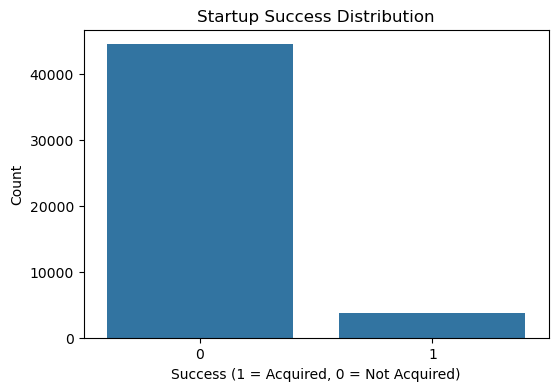

In [13]:
# Plot class distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="success")
plt.title("Startup Success Distribution")
plt.xlabel("Success (1 = Acquired, 0 = Not Acquired)")
plt.ylabel("Count")
plt.show()

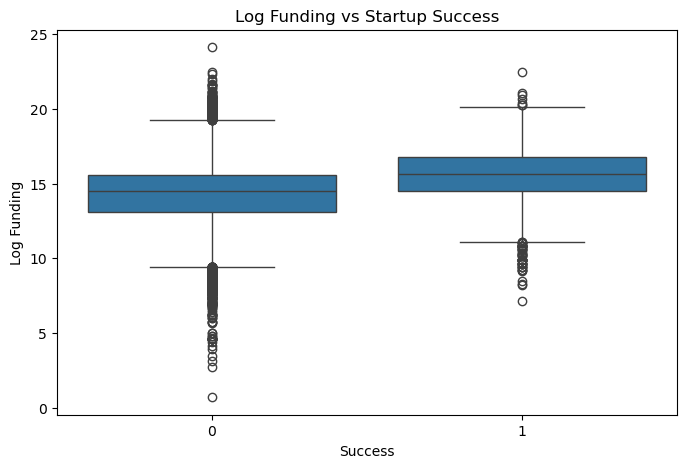

In [14]:
# Plot funding vs. success
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="success", y="log_funding")
plt.title("Log Funding vs Startup Success")
plt.xlabel("Success")
plt.ylabel("Log Funding")
plt.show()

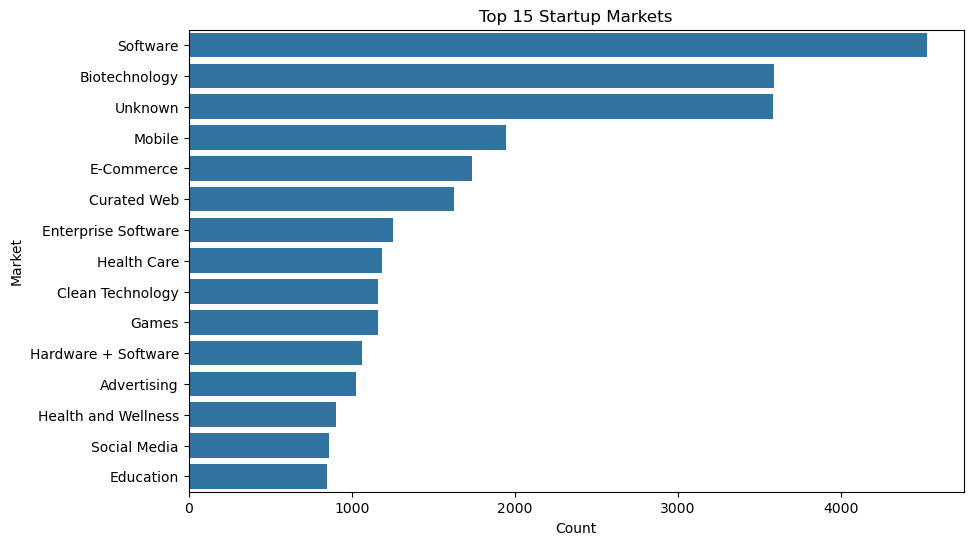

In [15]:
# PLot top industries and markets
top_markets = df["market"].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_markets.values, y=top_markets.index)
plt.title("Top 15 Startup Markets")
plt.xlabel("Count")
plt.ylabel("Market")
plt.show()

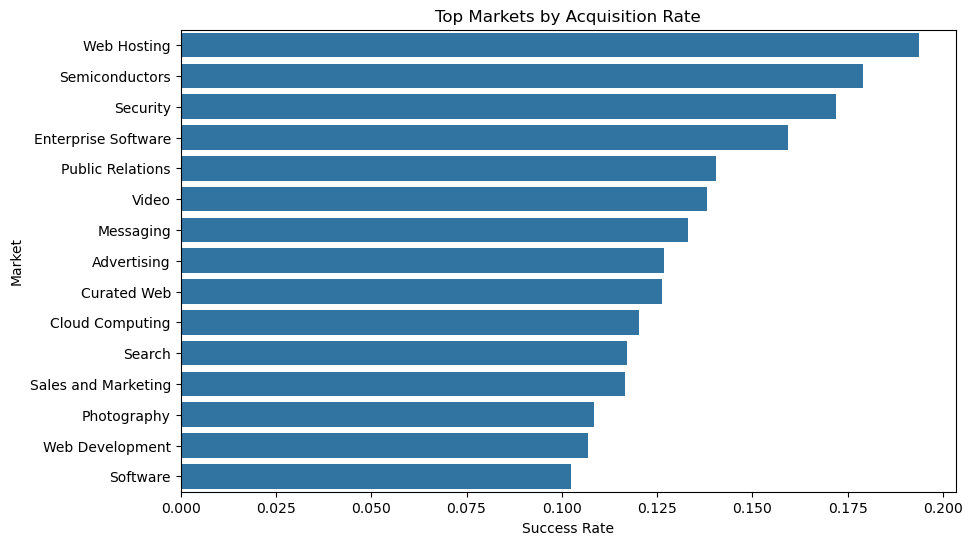

In [16]:
# Plot success rate by market
market_success = (
    df.groupby("market")["success"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
)

# keep only markets with enough data
market_success = market_success[market_success["count"] >= 100]
market_success = market_success.sort_values("mean", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=market_success["mean"], y=market_success.index)
plt.title("Top Markets by Acquisition Rate")
plt.xlabel("Success Rate")
plt.ylabel("Market")
plt.show()

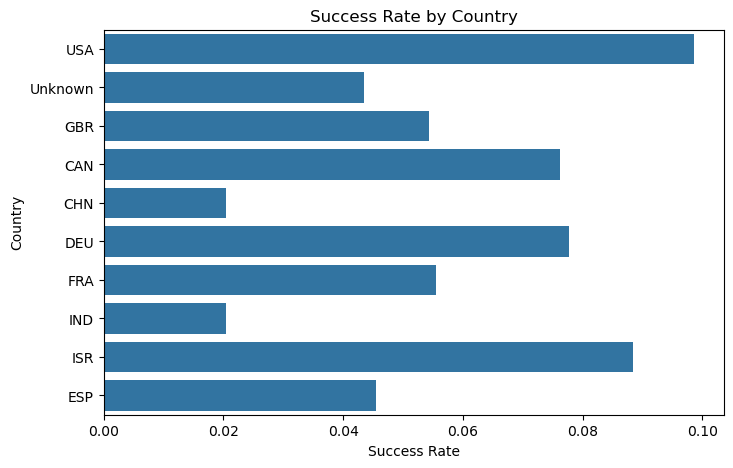

In [18]:
# Plot success rate by country
country_success = (
    df.groupby("country_code")["success"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
)

country_success = country_success[country_success["count"] >= 100].head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=country_success["mean"], y=country_success.index)
plt.title("Success Rate by Country")
plt.xlabel("Success Rate")
plt.ylabel("Country")
plt.show()

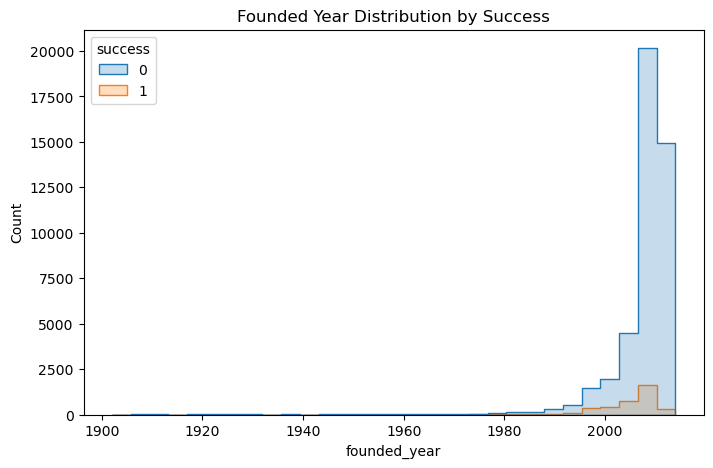

In [19]:
# Plot founding year vs. success
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="founded_year", hue="success", bins=30, element="step")
plt.title("Founded Year Distribution by Success")
plt.show()

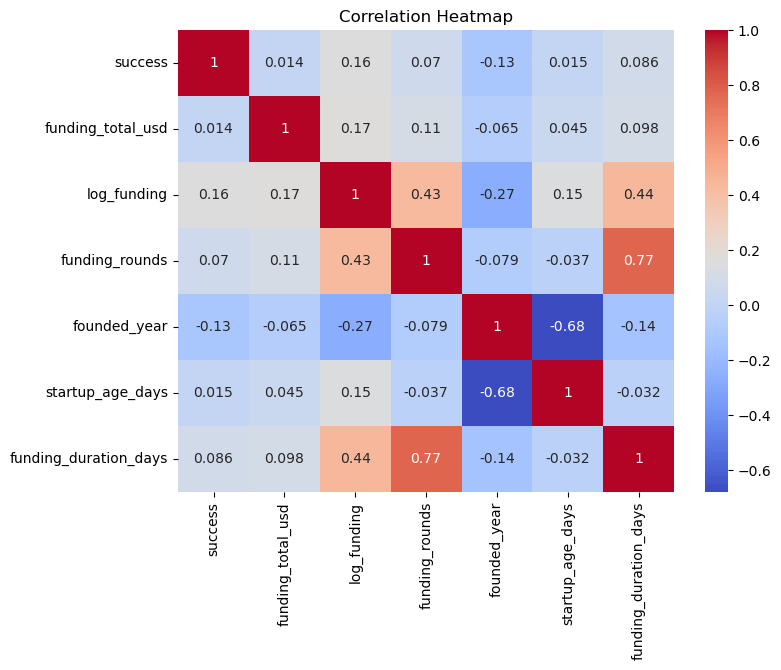

In [20]:
# Create correlation heatmap
numeric_cols = [
    "success", "funding_total_usd", "log_funding",
    "funding_rounds", "founded_year",
    "startup_age_days", "funding_duration_days"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()